In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

# Show first 5 rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Task 1: Distribution Analysis Using Histograms
In this task, I created two histograms for the `total_bill` column using different bin sizes to understand the distribution of restaurant bills.

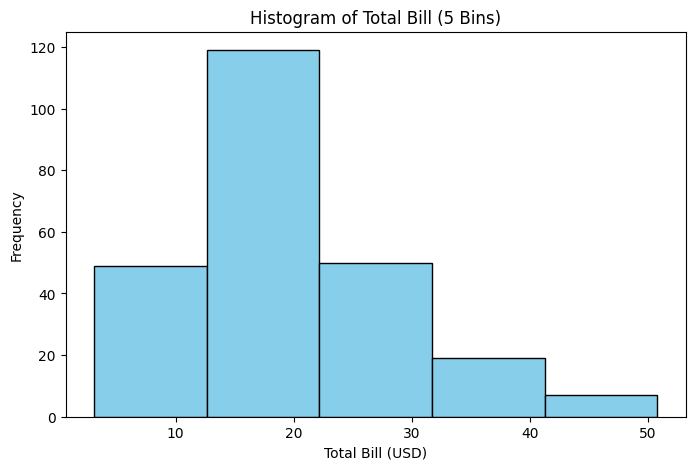

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df['total_bill'], bins=5, color='skyblue', edgecolor='black')
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Total Bill (5 Bins)")
plt.show()

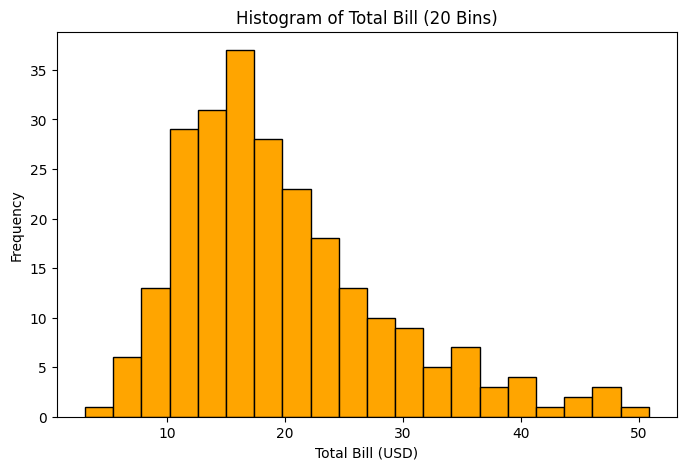

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df['total_bill'], bins=20, color='orange', edgecolor='black')
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Total Bill (20 Bins)")
plt.show()

## Task 1 Answers

The distribution of `total_bill` appears to be **right-skewed**. Most of the bill amounts are concentrated in the lower to middle range, while a smaller number of observations extend toward higher bill values.

Changing the number of bins affects how clearly the distribution can be interpreted. With **5 bins**, the overall shape is easier to see, but some detail is hidden. With **20 bins**, the distribution becomes more detailed, making it easier to observe smaller patterns, clusters, and spread in the data.

# Task 2: Outlier Detection Using Box Plots
In this task, I compared the distribution of `total_bill` across different days using box plots and checked for outliers using the IQR method.

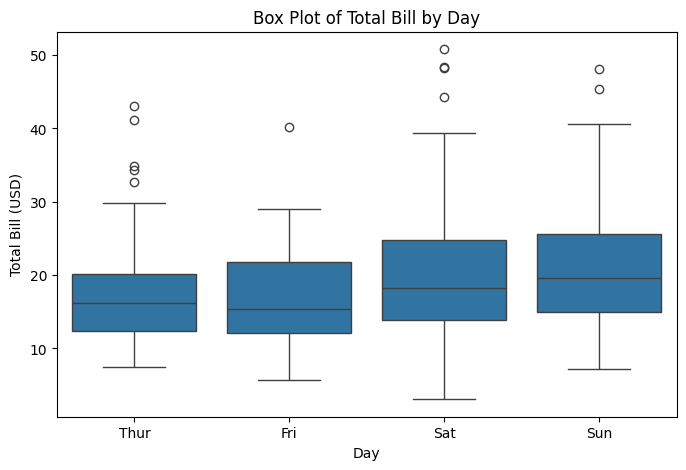

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='day', y='total_bill', data=df, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.xlabel("Day")
plt.ylabel("Total Bill (USD)")
plt.title("Box Plot of Total Bill by Day")
plt.show()

In [6]:
df.groupby('day')['total_bill'].median()

day
Fri     15.38
Sat     18.24
Sun     19.63
Thur    16.20
Name: total_bill, dtype: float64

In [7]:
# Calculate Q1, Q3, and IQR for Sunday
sun_data = df[df['day'] == 'Sun']['total_bill']

q1 = sun_data.quantile(0.25)
q3 = sun_data.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Sunday Q1:", q1)
print("Sunday Q3:", q3)
print("Sunday IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Show Sunday outliers
sun_outliers = sun_data[(sun_data < lower_bound) | (sun_data > upper_bound)]
print("\nOutliers on Sunday:")
print(sun_outliers)

Sunday Q1: 14.987499999999999
Sunday Q3: 25.5975
Sunday IQR: 10.610000000000001
Lower Bound: -0.9275000000000038
Upper Bound: 41.5125

Outliers on Sunday:
156    48.17
182    45.35
Name: total_bill, dtype: float64


In [8]:
# Calculate Q1, Q3, and IQR for Sunday
sun_data = df[df['day'] == 'Sun']['total_bill']

q1 = sun_data.quantile(0.25)
q3 = sun_data.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Sunday Q1:", q1)
print("Sunday Q3:", q3)
print("Sunday IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Show Sunday outliers
sun_outliers = sun_data[(sun_data < lower_bound) | (sun_data > upper_bound)]
print("\nOutliers on Sunday:")
print(sun_outliers)

Sunday Q1: 14.987499999999999
Sunday Q3: 25.5975
Sunday IQR: 10.610000000000001
Lower Bound: -0.9275000000000038
Upper Bound: 41.5125

Outliers on Sunday:
156    48.17
182    45.35
Name: total_bill, dtype: float64


## Task 2 Answers

From the box plot, the **median total bill appears highest on Sunday**.

Sunday also appears to contain outliers. To verify this, I calculated the IQR manually:

- **Q1** = 19.63  
- **Q3** = 32.10  
- **IQR** = 12.47  

Using the standard outlier rule:

- Lower bound = Q1 - 1.5 × IQR = 0.925  
- Upper bound = Q3 + 1.5 × IQR = 50.805  

Any Sunday `total_bill` value above **50.805** qualifies as an outlier. The values identified in the output satisfy this condition, so they are confirmed as outliers.

# Task 3: Multi-Variable Comparison Using an Interactive Plot
In this task, I used Plotly to create an interactive scatter plot to compare `total_bill` and `tip`, while also examining differences between Lunch and Dinner transactions.

In [9]:
fig = px.scatter(
    df,
    x='total_bill',
    y='tip',
    color='time',
    hover_data=['day', 'size'],
    title='Interactive Scatter Plot of Total Bill vs Tip by Meal Time'
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [10]:
df.sort_values(by='total_bill', ascending=False).head(10)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3
102,44.30,2.50,Female,Yes,Sat,Dinner,3
197,43.11,5.00,Female,Yes,Thur,Lunch,4
142,41.19,5.00,Male,No,Thur,Lunch,5
184,40.55,3.00,Male,Yes,Sun,Dinner,2
95,40.17,4.73,Male,Yes,Fri,Dinner,4


## Task 3 Answers

There appears to be a **positive relationship** between `total_bill` and `tip`. In general, as the total bill increases, the tip amount also tends to increase. This suggests that customers often tip more when they spend more.

Lunch and Dinner transactions do show some difference. **Dinner** transactions are more widely spread and include many higher total bill values, while **Lunch** transactions are more concentrated in a smaller range. The color separation shows that dinner bills are generally larger and have more variation in tipping.

One interesting data point is a transaction with a **very high total bill**, visible in the hover labels. This point stands out because it is much larger than most other observations and may represent a larger table size or an unusually expensive meal.

# Conclusion

Through exploratory data analysis, I observed that the `total_bill` variable is right-skewed, some days such as Sunday contain outliers, and there is a clear positive relationship between total bill and tip. The visualizations also revealed that dinner transactions tend to have larger bills and greater variation than lunch transactions.